In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for makign figures
%matplotlib inline

# New notebook

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
# Compile the dataset for the neural network
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
# in this example, were taking 3 characters to predict the fourth one
X, Y = [], [] # X is inputs to NN, Y is labels for each examples inside the X

for w in words: # First five for efficiency, change it later for the whole trainign set

    # print(w)
    context = [0] * block_size # padded context, padding with dots
    for ch in w + '.': # iterate over all character
        ix = stoi[ch] # get the character in the sequence
        X.append(context) # array X stores the current running context
        Y.append(ix) # build out array y of current character
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append, rolling window of context

X = torch.tensor(X)
Y = torch.tensor(Y)




In [6]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [ ]:
# build the dataset

def build_dataset(words): # Some list of words
    block_size = 3 # context length: how many characters do we take to predict the next one?
    X, Y = [], [] # builds list arrays X, Y

    for w in words:
        
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix] # crop and append
        
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

# Randomly shuffling,
# n1 = 80% of the words
# n2 = 90% of the words
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

# X, and Y for all three of the splits

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [7]:
# Imbedding lookup table
# Cramming in 2 dimensional space
# Each one of 27 characters, will have 2 dimensional imbedding
C = torch.randn((27, 2)) # 27 rows, 2 columns
# Initialized randomly


In [8]:
# Imbedding a single int
C[5] # Vector, 5th row of C

tensor([-0.5801,  0.0646])

In [9]:
# F.one_hot(torch.tensor(5), num_classes=27).dtype

In [10]:
# # One hot encoding, must be a tensor not int
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C # 26 dimensional vector of all zeroes, except for the fifth bit which is turned to 1
# # Think of this as the first layer of the NN
# # The weight matrix is C, encoding integers into one hot, and feeding them into NN
# # And this first layer basically imbed them
# # Indexing is easier 

In [11]:
# # How to simultaneously imbed all 32 x 3 integers sort in array X
# C[torch.tensor([5,6,7, 7, 7, 7])] # You can index lists, tensors, and repeat any rows
emb = C[X] # Can index multidimensional tensors
emb.shape

torch.Size([228146, 3, 2])

In [12]:
# Construct the hidden layer
W1 = torch.randn((6, 100)) # num of inputs, num of neurons (up to us) # weights
b1 = torch.rand(100) # bias


In [13]:
h = emb.view(-1 ,6) @ W1 + b1 # work for any size of emb.shape[0], or -1, pytorch will infer what it should be


In [14]:
# # torch.cat, concatonate 3 embeddings for each inputs
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape # grab all examples, first 0 zero index, and rest of examples
# # Three pieces individually
# # Squash them into 32 x 6 instead of 32 x 3 x 2

In [15]:
# torch.cat(torch.unbind(emb, 1), 1).shape # This gives a list of tensors exactly equivalent to torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1)
# # This is less efficient, its making new memory

In [16]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)
# Care about plus

In [17]:
h.shape

torch.Size([228146, 100])

In [18]:
W2 = torch.randn((100, 27)) # input 100, and output num of neurons is 27 (27 chars)
b2 = torch.rand(27) # bias


In [19]:
logits = h @ W2 + b2

In [20]:
logits.shape

torch.Size([228146, 27])

In [21]:
counts = logits.exp()

In [22]:
prob = counts / counts.sum(1, keepdim=True) # Normalize

In [ ]:
# loss = -prob[torch.arange(32), Y].log().mean() # iterate rows to columns Y
# loss # minimize this loss to get the Network to predict the correct character

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [ ]:
# torch.arange(32) # iterator over num 0-31

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [ ]:
# # Next character in the sequence
# Y 

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [ ]:
# ---------------Clean up the code------------------

In [234]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182580, 3]), torch.Size([182580]))

In [235]:
g = torch.Generator().manual_seed(2147483647) # for reproductibiloty
C = torch.randn((27, 10), generator=g) # 27, 2 -> 27, 10
W1 = torch.rand((30, 200), generator=g) # increase the size of the model, 6, 100 -> 6, 300
b1 = torch.randn((200), generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [236]:
sum(p.nelement() for p in parameters) # num of parameters in total

11897

In [237]:
for p in parameters:
    p.requires_grad = True

In [238]:
lre = torch.linspace(-3, 0, 1000) # makes 1000 nums between 0.001, 1
lrs = 10**lre # Stepping linearly between the learning rates, -3 -> 0.001, 0 -> 1

In [239]:
lri = []
lossi = []
stepi = []


In [240]:
for i in range(200000):
    # this is straight forward for now cause were only fitting 32 examples
    # were overfitting a single batch, many parameters for few examples
    
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # Forward pass
    emb = C[Xtr[ix]] # (32, 3, 2) not (200k, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)

    # # classification
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims=True)
    # loss = -prob[torch.arange(32), Y].log().mean()
    # #-----

    # Using this will not make new all the intermediate tensors, and its inefficient
    # pytorch will cluster up all the operations, and backward pass can make more efficient

    # Significantly more numerically well behave
    loss = F.cross_entropy(logits, Ytr[ix]) 

    # print(loss.item())


    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    # lr = lrs[i] # iterating a _ time, begginning is low, the end will be faster
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay # 10x slower
    for p in parameters:
        p.data += -lr * p.grad # we dunno if were too slow or too fast
        # How do we determine the step rate and the direction?
        # Find at which rate the the loss explodes
    
    # Find a decent learning rate, then train it for a while,
    # Then start learning rate decay

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())

# unable to achieve exactly 0
# It takes time

# In practice people perform these tasks in mini batches of the data
# randomly select some portion of the data set

# Mini batches make things a lot faster, but the quality of the gradient is low
# The direction is not as reliable, its not the actualy direction of the gradient
# But it's good enough, but its better to approximate the gradient and take more steps
# than rather have the exact gradients with fewer steps

# Keep training

# If the dev, and traing gets further, 
# The neural net will start becoming over fit

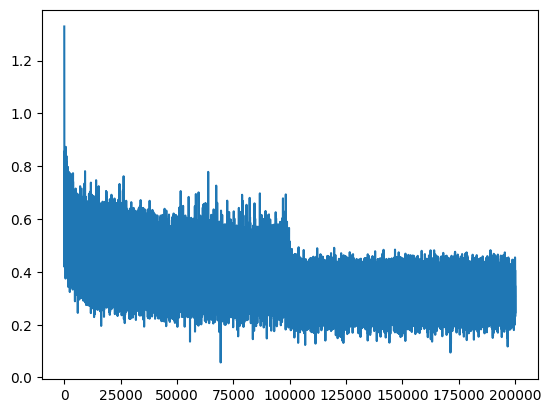

In [241]:
plt.plot(stepi, lossi)

In [242]:
# Can continue tuning
# Can continue playing with the size of the neural net
# Increase nums of words/characters as inputs
# Further imrpove the loss

In [243]:
emb = C[Xtr] # (32, 3, 2) not (200k, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1222, grad_fn=<NllLossBackward0>)

In [244]:
emb = C[Xdev] # (32, 3, 2) not (200k, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

# training loss and test losses are almost equal, we are not over fitting
# so that means our network are small
# underfitting

tensor(2.1545, grad_fn=<NllLossBackward0>)

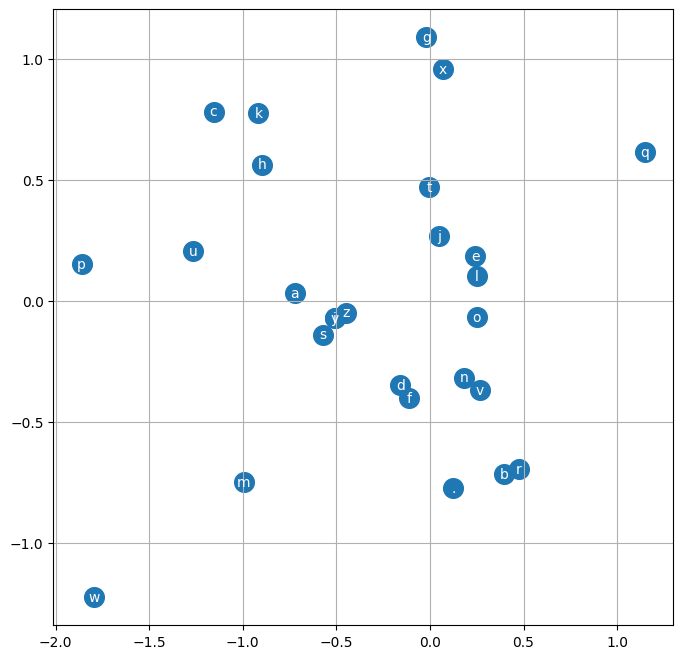

In [229]:
# visualize the embedding vector, that are trained by the neural nets
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center",va="center", color='white')
plt.grid('minor')

# Cluster = neural nets think theyre similar, interchangable
# Stand alone = special embedding 

In [111]:
# torch.randint(0, X.shape[0], (32,)) # creates integer that index into our dataset

In [ ]:
# # Suppose
# logits = torch.tensor([-5, -3, 0, 5]) # any offsets wil produce the exact same probabilities

# # but in pytorch it will subtract from teh positive amount
# logits = torch.tensor([-5, -3, 0, 100]) - 100 # this is good

# # Using cross-entropy would make both forward and backward pass more efficient


# counts = logits.exp() 
# # if you pass in a very negative number it will be zero
# # If you pass in a very positive number, you run out of floating range
# probs = counts / counts.sum()
# probs

tensor([4.5079e-05, 3.3309e-04, 6.6903e-03, 9.9293e-01])

In [ ]:
# training split, dev/validation split, test split
# 80%           , 10%                 , 10% roughly
# Lots of hyper parameters and settings that are defining in a neural net
# only test the loss on the test split, to avoid overfitting

In [245]:
# sample from the model
g = torch.Generator().manual_seed(2147483747 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

khalim.
stanusiah.
katen.
cel.
roseyianichushir.
lace.
leigh.
delim.
inda.
taniem.
natt.
shawa.
xhanthos.
aklee.
alen.
krisson.
makim.
ame.
kamonifo.
leigh.
